In [1]:
import sys
print(sys.executable)

C:\Python38\python.exe


In [3]:
from localtfem.modified_dubiner.jacobi import jacobi_coeffs_sym

print(jacobi_coeffs_sym(4, 0, 0))

[3/8, 0, 0, 0, -55/24]


In [5]:
from localtfem.modified_dubiner.dubiner import DubinerBasis

basis = DubinerBasis(p=3)

print(basis.n_modes())

10


In [8]:
from localtfem.quadrature.legendre import gauss_legendre 
x, w = gauss_legendre(4)

print("Nodes:")
print(x)

print("\nWeights:")
print(w)

print("\nSum of weights:", w.sum())


Nodes:
[-0.86113631 -0.33998104  0.33998104  0.86113631]

Weights:
[0.34785485 0.65214515 0.65214515 0.34785485]

Sum of weights: 2.0


In [25]:
from sympy import N
import numpy as np

from localtfem.modified_dubiner.dubiner_sym import dubiner_basis as sym_dubiner_basis, xi, eta
from localtfem.modified_dubiner.dubiner import DubinerBasis

# ------------------------------------------------------------
# build basis
# ------------------------------------------------------------
p = 2

sym_basis = sym_dubiner_basis(p)
num_basis = DubinerBasis(p)

# ------------------------------------------------------------
# test point
# ------------------------------------------------------------
xi0 = -1.0
eta0 = -1.0

# ------------------------------------------------------------
# evaluate symbolic basis
# ------------------------------------------------------------
sym_vals = [
    float(N(b.subs({xi: xi0, eta: eta0})))
    for b in sym_basis
]

# ------------------------------------------------------------
# evaluate numerical basis (IMPORTANT FIX)
# ------------------------------------------------------------
num_vals = num_basis.evaluate(xi0, eta0)

# ------------------------------------------------------------
# compare
# ------------------------------------------------------------
diff = np.array(sym_vals) - np.array(num_vals)

print("symbolic values:", sym_vals)
print("numeric values: ", num_vals)
print("difference:     ", diff)
print("max error:      ", np.max(np.abs(diff)))

symbolic values: [0.0, 1.0, 0.0, 1.0, 1.0, 1.0]
numeric values:  [ 0.    0.25  0.    0.    0.   -0.  ]
difference:      [0.   0.75 0.   1.   1.   1.  ]
max error:       1.0


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify

from localtfem.modified_dubiner.dubiner import DubinerBasis
from localtfem.modified_dubiner.dubiner_sym import vertex_modes, xi, eta


# ------------------------------------------------------------
# build reference TRIANGLE grid
# ------------------------------------------------------------
N = 120
xi_vals = np.linspace(-1, 1, N)
eta_vals = np.linspace(-1, 1, N)

XI, ETA = np.meshgrid(xi_vals, eta_vals)

# TRUE triangle mask (collapsed simplex)
mask = ETA <= 1 - XI


# ------------------------------------------------------------
# numerical basis
# ------------------------------------------------------------
basis = DubinerBasis(p=1)

num = basis.evaluate(XI, ETA)  # full vector at once

num_A = num[..., 0]
num_B = num[..., 1]
num_C = num[..., 2]


# apply mask
num_A = np.where(mask, num_A, np.nan)
num_B = np.where(mask, num_B, np.nan)
num_C = np.where(mask, num_C, np.nan)


# ------------------------------------------------------------
# symbolic vertex modes
# ------------------------------------------------------------
A_sym, B_sym, C_sym = vertex_modes()

A_f = lambdify((xi, eta), A_sym, "numpy")
B_f = lambdify((xi, eta), B_sym, "numpy")
C_f = lambdify((xi, eta), C_sym, "numpy")

sym_A = A_f(XI, ETA)
sym_B = B_f(XI, ETA)
sym_C = C_f(XI, ETA)

sym_A = np.where(mask, sym_A, np.nan)
sym_B = np.where(mask, sym_B, np.nan)
sym_C = np.where(mask, sym_C, np.nan)


# ------------------------------------------------------------
# plotting
# ------------------------------------------------------------
def plot(title, s, n):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].contourf(XI, ETA, s, levels=25)
    ax[0].set_title(title + " (symbolic)")

    ax[1].contourf(XI, ETA, n, levels=25)
    ax[1].set_title(title + " (numerical)")

    plt.tight_layout()
    plt.show()


plot("Vertex A", sym_A, num_A)
plot("Vertex B", sym_B, num_B)
plot("Vertex C", sym_C, num_C)

ValueError: operands could not be broadcast together with shapes (120,120) (3,120) () 

In [73]:
import importlib
import localtfem.modified_dubiner.dubiner_sym as ds

importlib.reload(ds)

from localtfem.modified_dubiner.dubiner_sym import vertex_modes, xi, eta

import localtfem.modified_dubiner.dubiner_sym as ds

print(dir(ds))

['Rational', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'annotations', 'dubiner_basis', 'dubiner_mode', 'edge_mode_m', 'eta', 'eval_basis', 'expand', 'interior_mode', 'jacobi_P', 'jacobian', 'legendre', 'shifted_legendre_weight', 'simplify', 'symbols', 'vertex_modes', 'xi']


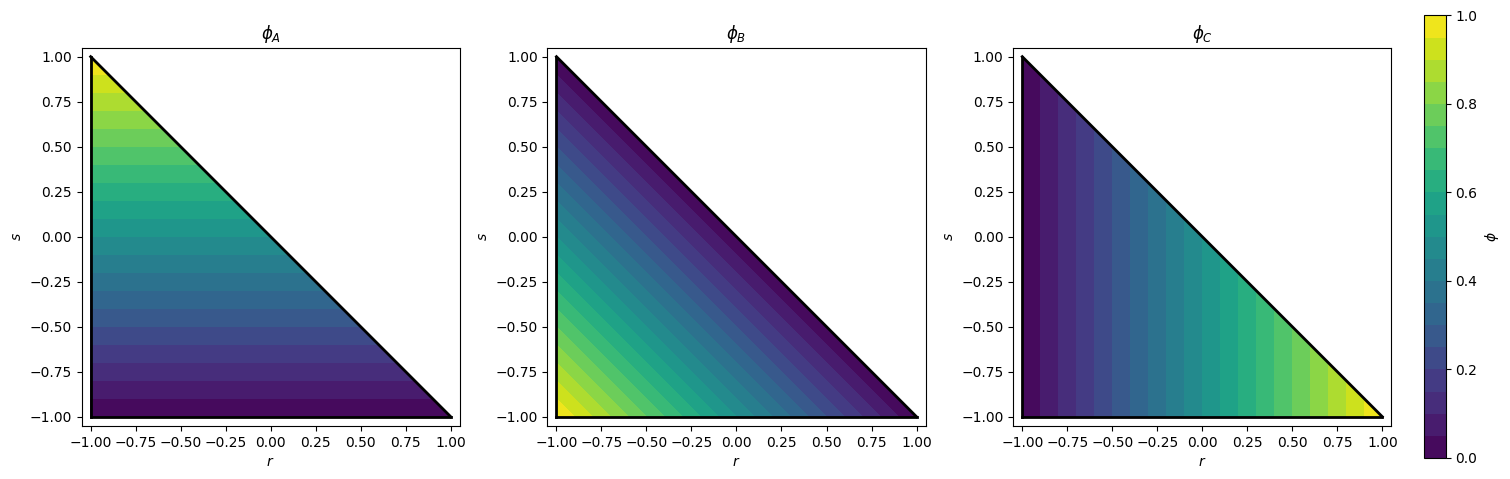

In [117]:
import numpy as np
import matplotlib.pyplot as plt

from localtfem.geometry.reference_triangle import square_to_triangle

# ------------------------------------------------------------
# Grid in collapsed coordinates
# ------------------------------------------------------------

N = 150

xi = np.linspace(-1, 1, N)
eta = np.linspace(-1, 1, N)

XI, ETA = np.meshgrid(xi, eta)

# ------------------------------------------------------------
# Map to reference triangle
# ------------------------------------------------------------

R, S = square_to_triangle(XI, ETA)

# ------------------------------------------------------------
# Vertex basis functions
# ------------------------------------------------------------

phiA = 0.5 * (1 + ETA)
phiB = 0.25 * (1 - XI) * (1 - ETA)
phiC = 0.25 * (1 + XI) * (1 - ETA)

phis = [phiA, phiB, phiC]
titles = [
    r"$\phi_A$",
    r"$\phi_B$",
    r"$\phi_C$",
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

levels = np.linspace(0, 1, 21)

mappable = None

for ax, phi, title in zip(axes, phis, titles):

    cf = ax.contourf(
        R,
        S,
        phi,
        levels=levels,
        vmin=0,
        vmax=1,
        cmap="viridis",
    )

    mappable = cf

    # reference triangle
    ax.plot([-1, -1], [-1, 1], "k", lw=2)
    ax.plot([-1,  1], [-1, -1], "k", lw=2)
    ax.plot([-1,  1], [ 1, -1], "k", lw=2)

    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)

    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$s$")
    ax.set_title(title)

# Shared colorbar
cbar = fig.colorbar(
    mappable,
    ax=axes,
    shrink=0.9,
    pad=0.02,
)

cbar.set_label(r"$\phi$")
cbar.set_ticks(np.linspace(0, 1, 6))

plt.show()

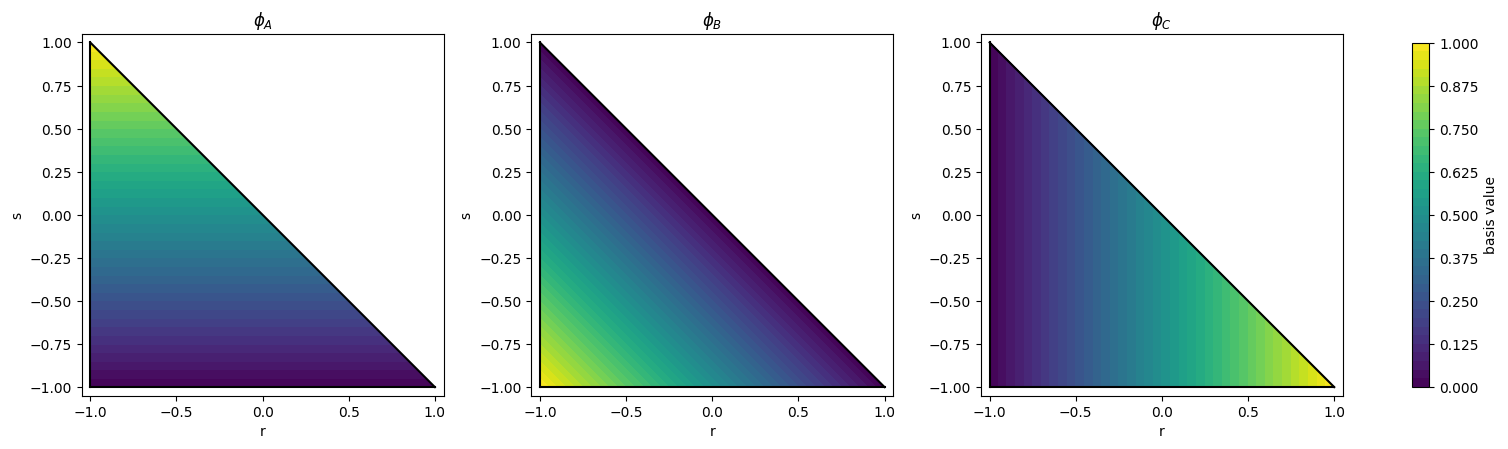

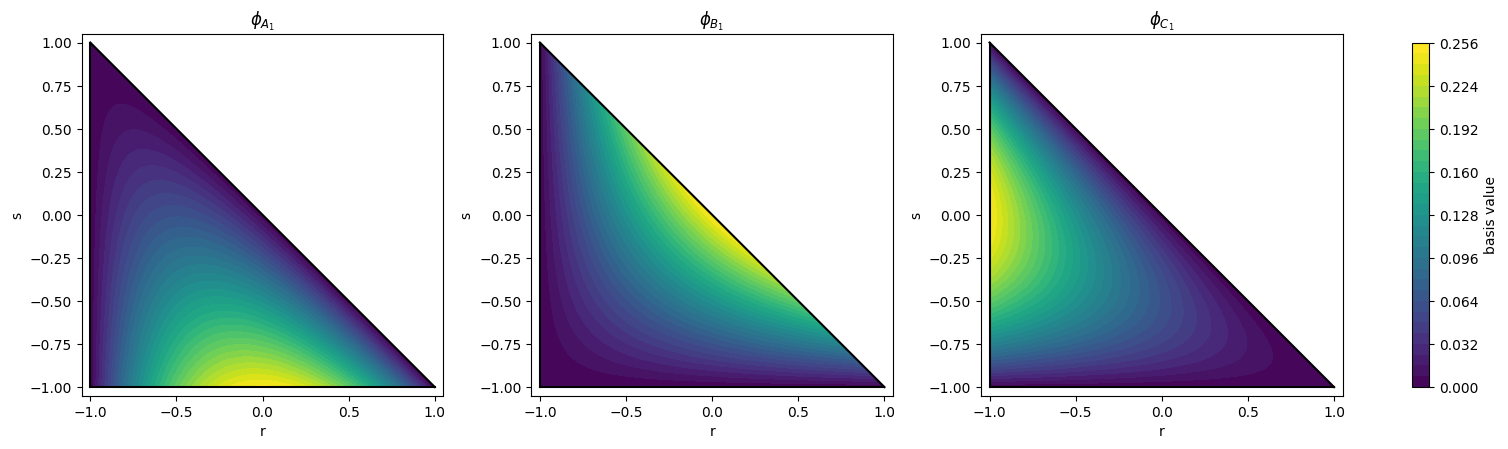

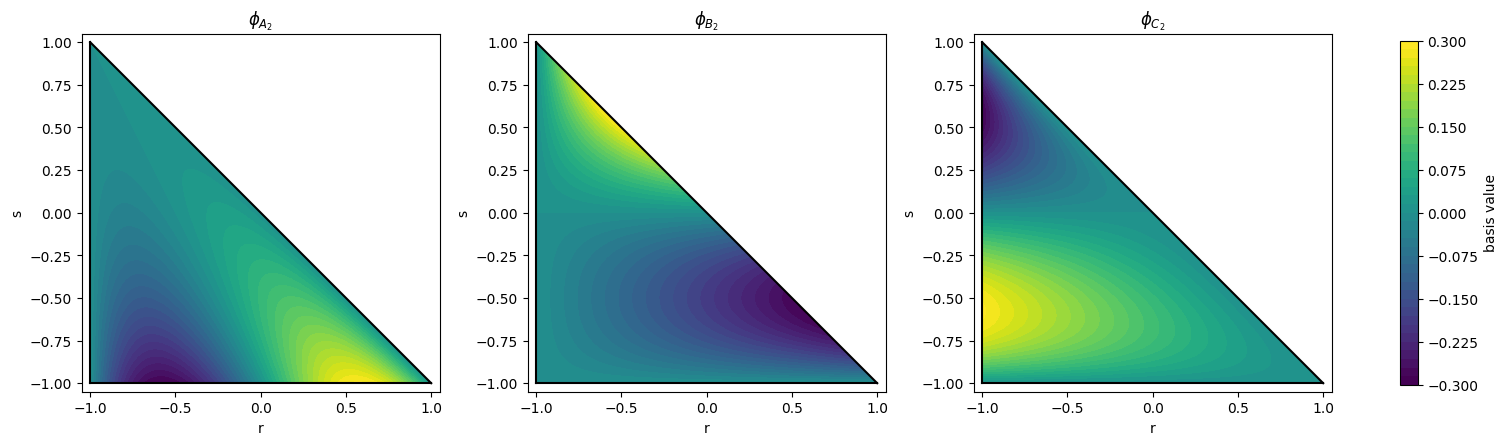

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from localtfem.modified_dubiner.dubiner import DubinerBasis
from localtfem.geometry.reference_triangle import square_to_triangle

# ------------------------------------------------------------
# grid in square
# ------------------------------------------------------------

n = 200
xi = np.linspace(-1, 1, n)
eta = np.linspace(-1, 1, n)

XI, ETA = np.meshgrid(xi, eta, indexing="xy")

# map ONLY for visualization
R, S = square_to_triangle(XI, ETA)

# ------------------------------------------------------------
# evaluate basis
# ------------------------------------------------------------

basis = DubinerBasis(3)
vals = basis.evaluate(XI, ETA)

phiA = vals[..., 0]
phiB = vals[..., 1]
phiC = vals[..., 2]

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

phis = [phiA, phiB, phiC]
titles = [r"$\phi_A$", r"$\phi_B$", r"$\phi_C$"]

vmin = min(phiA.min(), phiB.min(), phiC.min())
vmax = max(phiA.max(), phiB.max(), phiC.max())

for ax, phi, title in zip(axes, phis, titles):

    cf = ax.contourf(
        R, S,
        phi,
        levels=40,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    # triangle boundary
    ax.plot([-1, -1], [-1, 1], "k")
    ax.plot([-1, 1], [-1, -1], "k")
    ax.plot([-1, 1], [1, -1], "k")

    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)

    ax.set_title(title)
    ax.set_xlabel("r")
    ax.set_ylabel("s")

# single shared colorbar (correct placement)
fig.colorbar(cf, ax=axes, shrink=0.7, label="basis value")

plt.show()


fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
edge_modes = [3, 4, 5]
edge_titles = [r"$\phi_{A_1}$", r"$\phi_{B_1}$", r"$\phi_{C_1}$"]

vmin = np.min(vals[..., edge_modes])
vmax = np.max(vals[..., edge_modes])

for ax, mode, title in zip(axes2, edge_modes, edge_titles):

    cf = ax.contourf(
        R, S,
        vals[..., mode],
        levels=40,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    ax.plot([-1, -1], [-1, 1], "k")
    ax.plot([-1, 1], [-1, -1], "k")
    ax.plot([-1, 1], [1, -1], "k")

    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)

    ax.set_title(title)
    ax.set_xlabel("r")
    ax.set_ylabel("s")

fig2.colorbar(cf, ax=axes2, shrink=0.7, label="basis value")

plt.show()


fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
edge_modes = [6, 7, 8]


edge_titles = [r"$\phi_{A_2}$", r"$\phi_{B_2}$", r"$\phi_{C_2}$"]

vmin = np.min(vals[..., edge_modes])
vmax = np.max(vals[..., edge_modes])

for ax, mode, title in zip(axes3, edge_modes, edge_titles):

    cf = ax.contourf(
        R, S,
        vals[..., mode],
        levels=40,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    ax.plot([-1, -1], [-1, 1], "k")
    ax.plot([-1, 1], [-1, -1], "k")
    ax.plot([-1, 1], [1, -1], "k")

    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)

    ax.set_title(title)
    ax.set_xlabel("r")
    ax.set_ylabel("s")

fig3.colorbar(cf, ax=axes3, shrink=0.7, label="basis value")

plt.show()

In [3]:
basis = DubinerBasis(3)

print(basis.evaluate(xi, eta).shape)

for i, mode in enumerate(basis.modes):
    print(i, mode.evaluate(xi, eta).shape)

(200, 10)
0 (200,)
1 (200,)
2 (200,)
3 (200,)
4 (200,)
5 (200,)
6 (200,)
7 (200,)
8 (200,)
9 (200,)


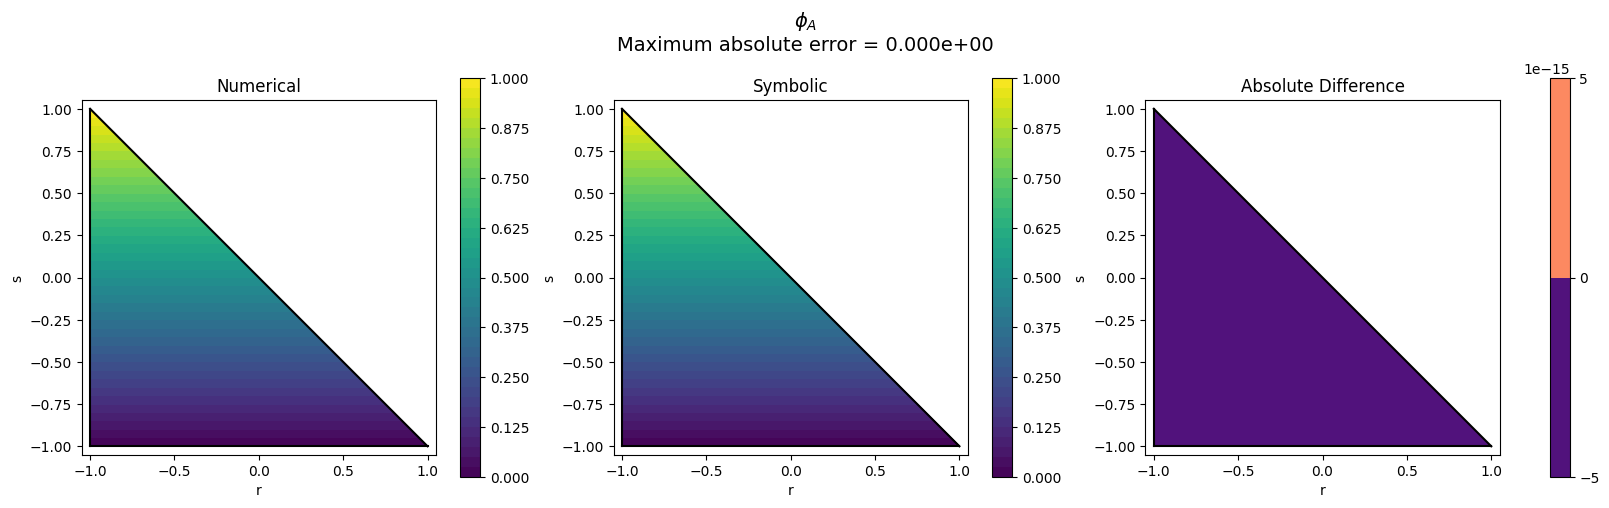

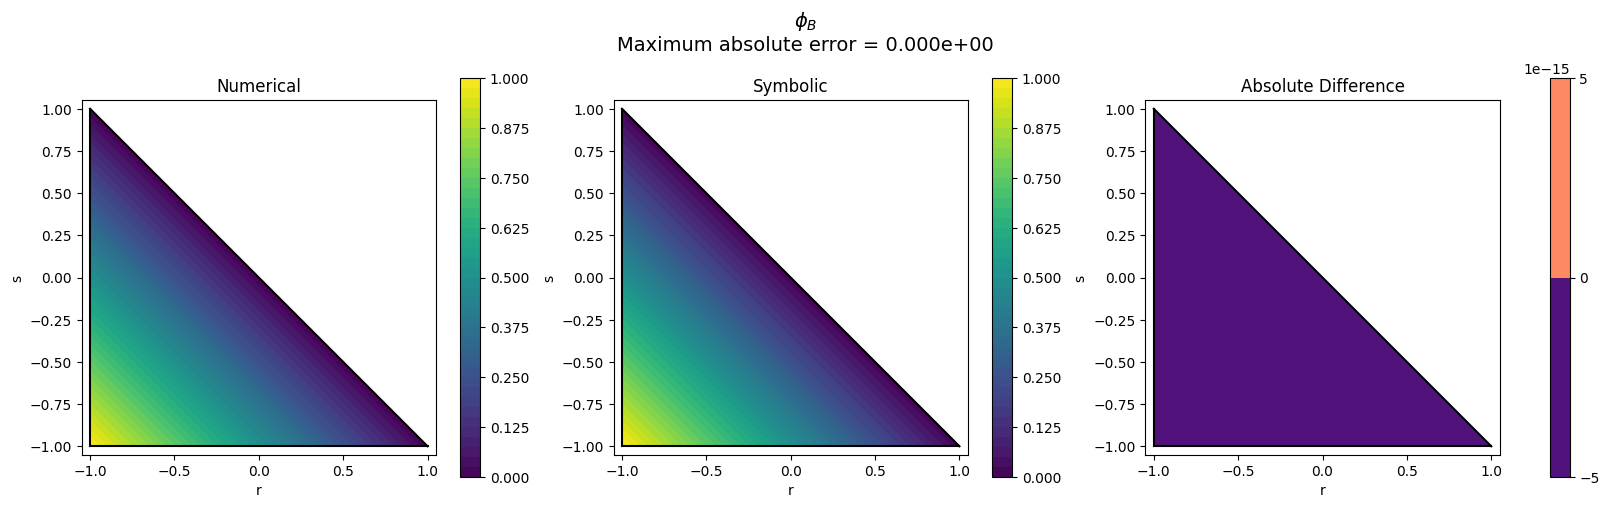

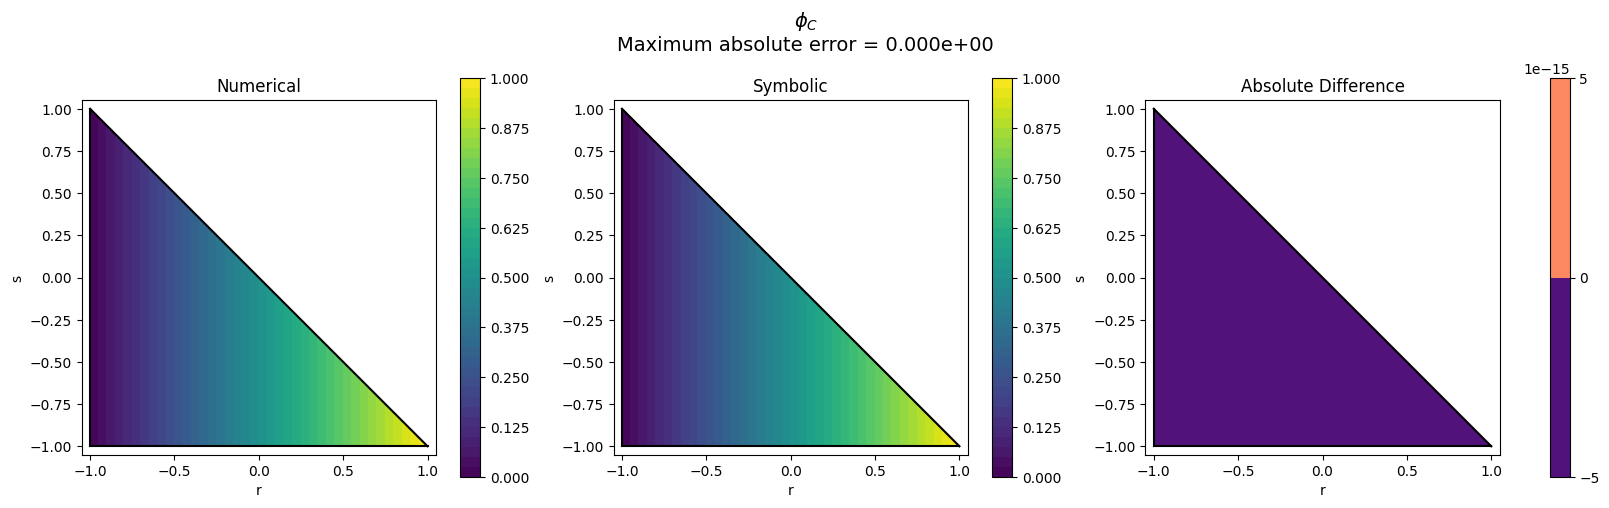

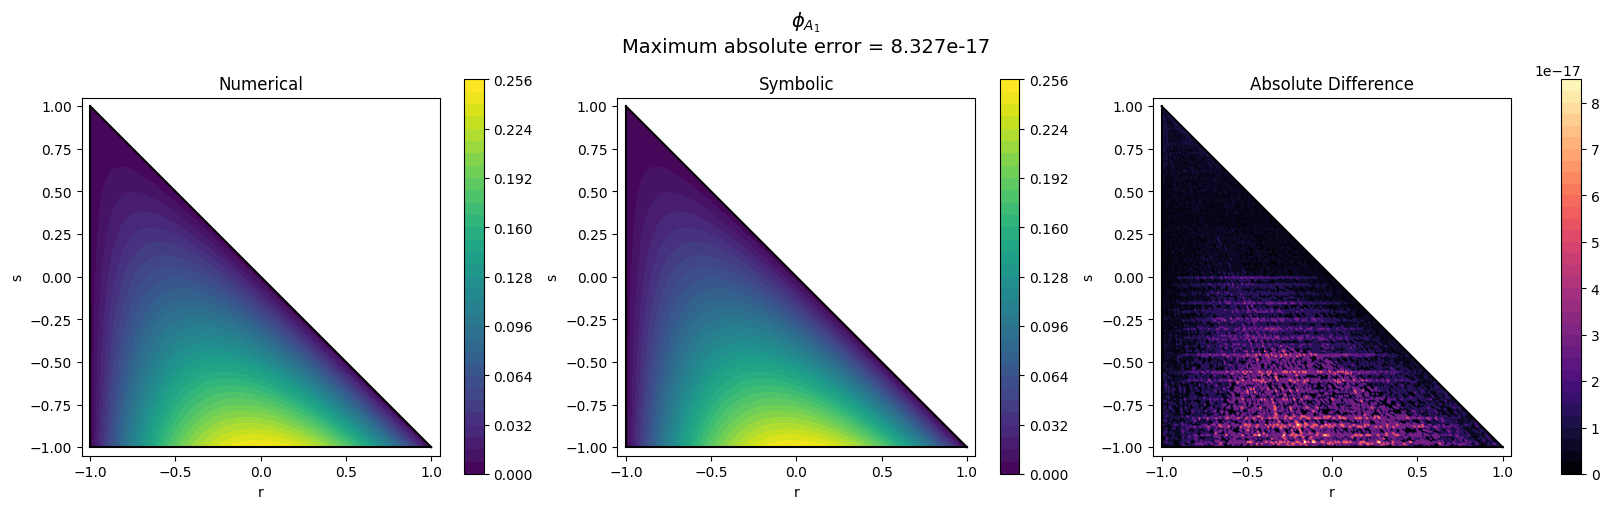

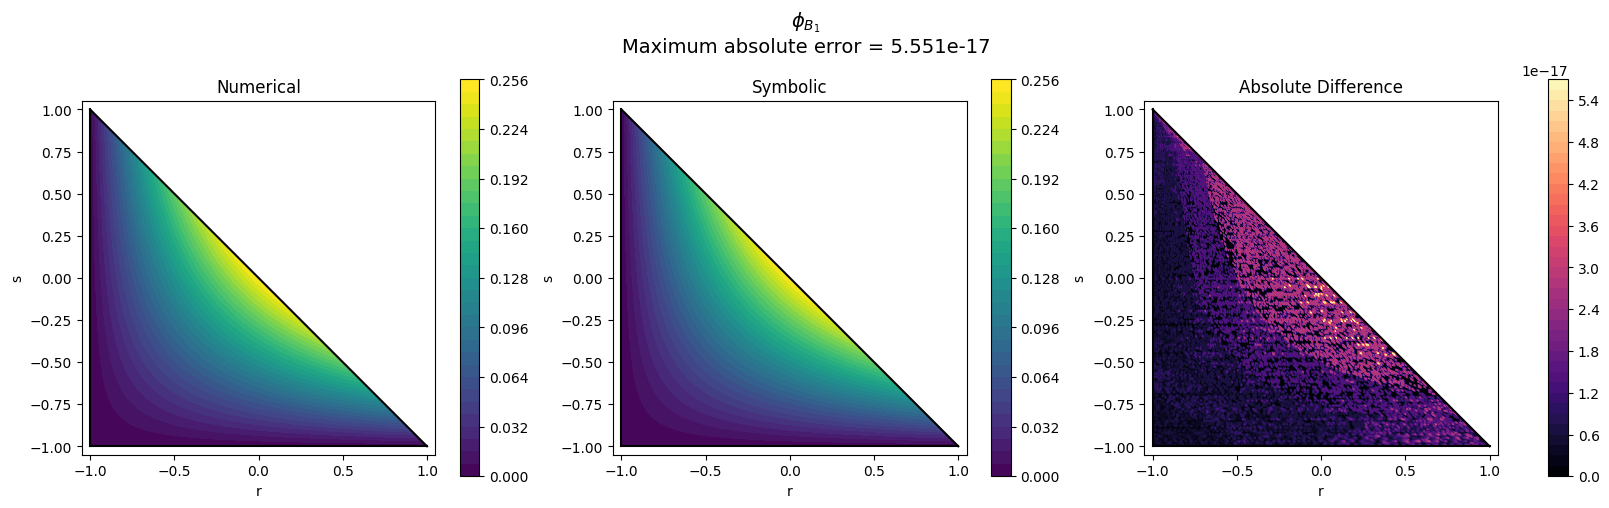

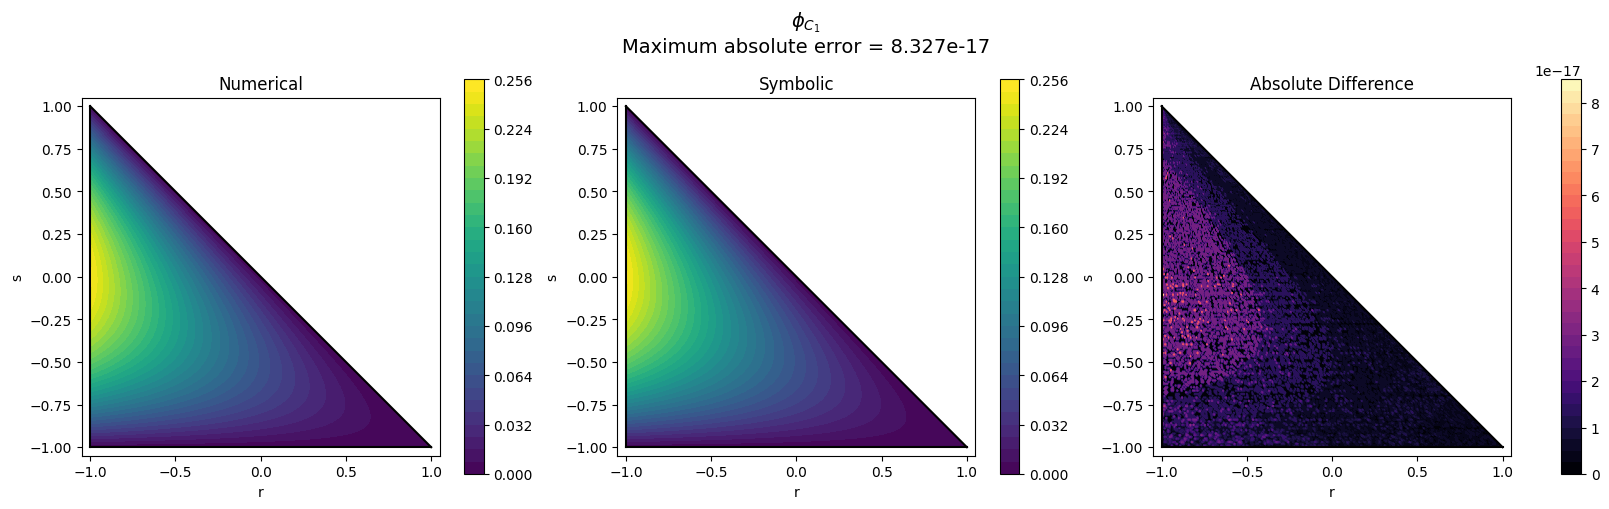

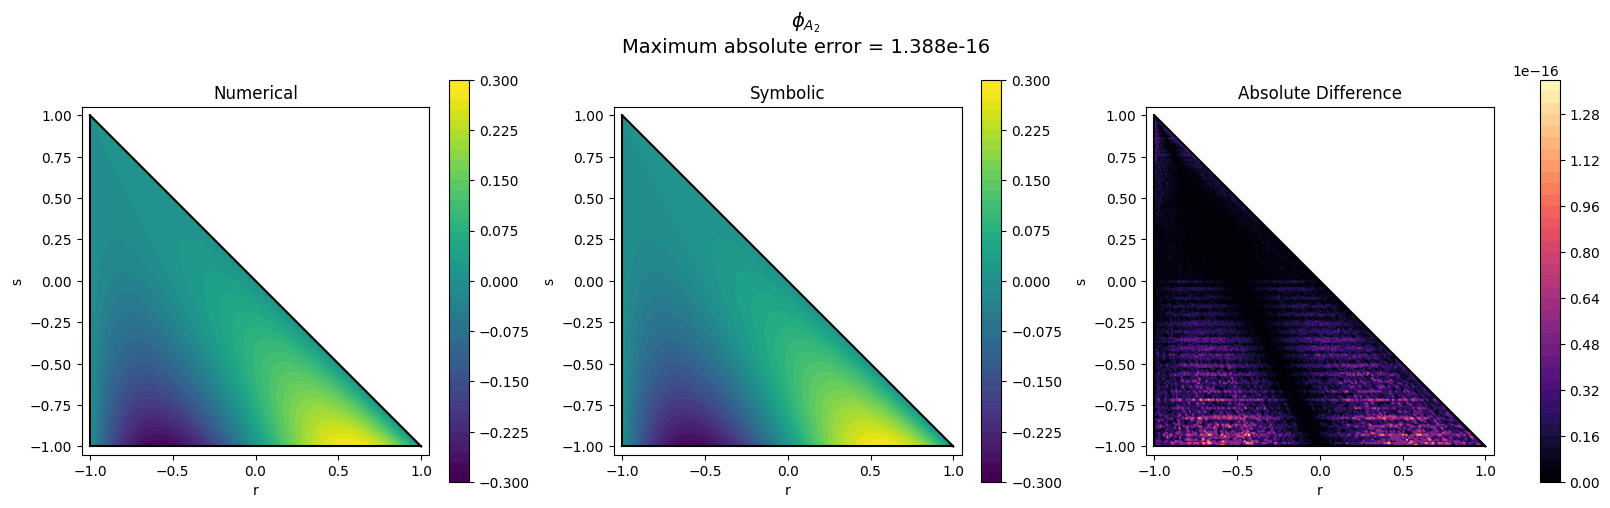

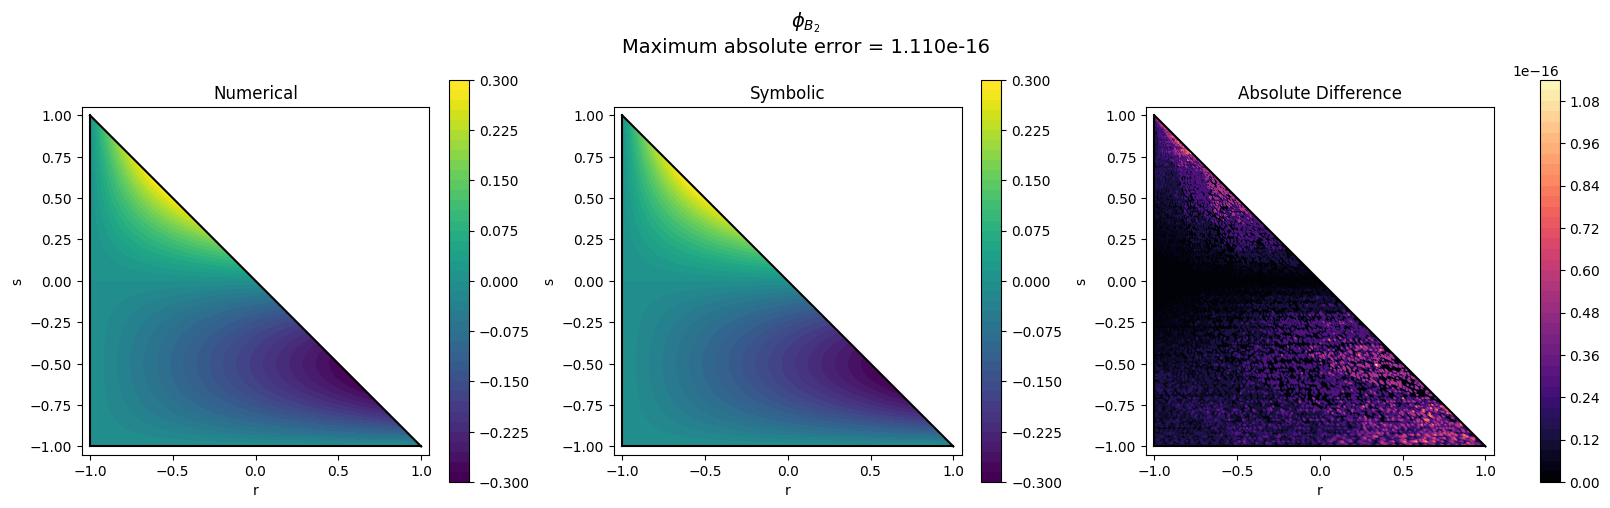

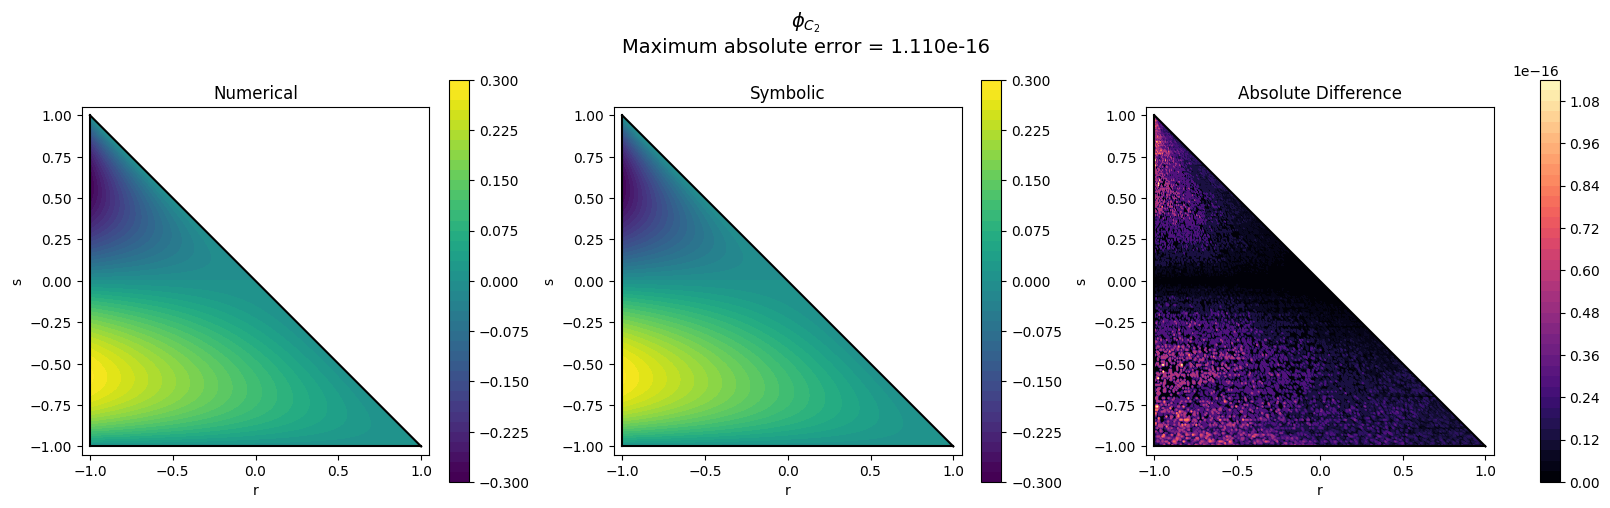

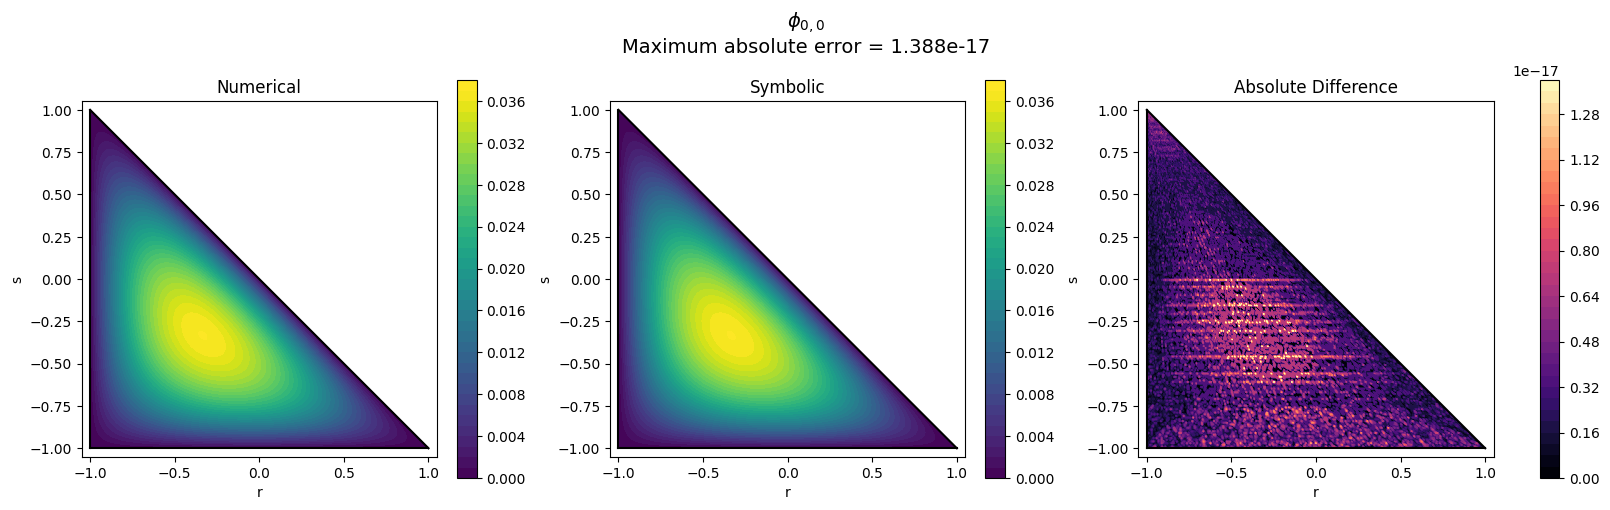

Maximum absolute error over all modes = 1.388e-16


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify

from localtfem.modified_dubiner.dubiner import DubinerBasis
from localtfem.modified_dubiner.dubiner_sym import (
    dubiner_basis,
    xi,
    eta,
)
from localtfem.geometry.reference_triangle import square_to_triangle


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

p = 3
n = 200

# ------------------------------------------------------------
# Evaluation grid
# ------------------------------------------------------------

xi_vals = np.linspace(-1, 1, n)
eta_vals = np.linspace(-1, 1, n)

XI, ETA = np.meshgrid(xi_vals, eta_vals, indexing="xy")

# Triangle coordinates for plotting
R, S = square_to_triangle(XI, ETA)

# ------------------------------------------------------------
# Numerical basis
# ------------------------------------------------------------

num_basis = DubinerBasis(p)
num_vals = num_basis.evaluate(XI, ETA)

# ------------------------------------------------------------
# Symbolic basis
# ------------------------------------------------------------

sym_basis = dubiner_basis(p)

sym_funcs = [
    lambdify((xi, eta), expr, modules="numpy")
    for expr in sym_basis
]

sym_vals = np.stack(
    [f(XI, ETA) for f in sym_funcs],
    axis=-1,
)

# ------------------------------------------------------------
# Absolute error
# ------------------------------------------------------------

abs_error = np.abs(num_vals - sym_vals)

# ------------------------------------------------------------
# Names
# ------------------------------------------------------------

titles = [
    r"$\phi_A$",
    r"$\phi_B$",
    r"$\phi_C$",
    r"$\phi_{ A_1}$",
    r"$\phi_{ B_1}$",
    r"$\phi_{ C_1}$",
    r"$\phi_{ A_2}$",
    r"$\phi_{ B_2}$",
    r"$\phi_{ C_2}$",
    r"$\phi_{0,0}$",
]

assert len(titles) == num_vals.shape[-1]

# ------------------------------------------------------------
# Plot every basis function
# ------------------------------------------------------------

for mode, title in enumerate(titles):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 5),
        constrained_layout=True,
    )

    numerical = num_vals[..., mode]
    symbolic = sym_vals[..., mode]
    error = abs_error[..., mode]

    # Use common colour scale for numerical/symbolic
    vmin = min(numerical.min(), symbolic.min())
    vmax = max(numerical.max(), symbolic.max())

    datasets = [
        numerical,
        symbolic,
        error,
    ]

    subtitles = [
        "Numerical",
        "Symbolic",
        "Absolute Difference",
    ]

    cmaps = [
        "viridis",
        "viridis",
        "magma",
    ]

    for i, (ax, data, subtitle, cmap) in enumerate(
        zip(axes, datasets, subtitles, cmaps)
    ):

        if i < 2:
            cf = ax.contourf(
                R,
                S,
                data,
                levels=40,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )
        else:
            cf = ax.contourf(
                R,
                S,
                data,
                levels=40,
                cmap=cmap,
            )

        # Triangle boundary
        ax.plot([-1, -1], [-1, 1], "k")
        ax.plot([-1, 1], [-1, -1], "k")
        ax.plot([-1, 1], [1, -1], "k")

        ax.set_aspect("equal")
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)

        ax.set_xlabel("r")
        ax.set_ylabel("s")
        ax.set_title(subtitle)

        plt.colorbar(cf, ax=ax)

    fig.suptitle(
        f"{title}\nMaximum absolute error = {error.max():.3e}",
        fontsize=14,
    )

    plt.show()

# ------------------------------------------------------------
# Overall verification
# ------------------------------------------------------------

print(f"Maximum absolute error over all modes = {abs_error.max():.3e}")

In [6]:
from localtfem.modified_dubiner import dubiner_sym
from IPython.display import display

M = dubiner_sym.symbolic_mass_matrix(p=3, integrate=True)
print(M)
display(M)

Matrix([[1/3, 1/6, 1/6, 1/30, 1/15, 1/15, 0, 0, 0, 1/90], [1/6, 1/3, 1/6, 1/15, 1/30, 1/15, -1/30, -1/30, 1/15, 1/90], [1/6, 1/6, 1/3, 1/15, 1/15, 1/30, 1/30, -1/15, 1/30, 1/90], [1/30, 1/15, 1/15, 1/45, 1/90, 1/90, 0, -1/70, 1/70, 1/315], [1/15, 1/30, 1/15, 1/90, 1/45, 1/90, 1/210, -1/105, 1/210, 1/315], [1/15, 1/15, 1/30, 1/90, 1/90, 1/45, -1/210, -1/210, 1/105, 1/315], [0, -1/30, 1/30, 0, 1/210, -1/210, 3/140, -1/140, -1/140, 0], [0, -1/30, -1/15, -1/70, -1/105, -1/210, -1/140, 1/35, -1/70, -1/420], [0, 1/15, 1/30, 1/70, 1/210, 1/105, -1/140, -1/70, 1/35, 1/420], [1/90, 1/90, 1/90, 1/315, 1/315, 1/315, 0, -1/420, 1/420, 1/1260]])


Matrix([
[ 1/3,   1/6,   1/6,  1/30,   1/15,   1/15,      0,      0,      0,   1/90],
[ 1/6,   1/3,   1/6,  1/15,   1/30,   1/15,  -1/30,  -1/30,   1/15,   1/90],
[ 1/6,   1/6,   1/3,  1/15,   1/15,   1/30,   1/30,  -1/15,   1/30,   1/90],
[1/30,  1/15,  1/15,  1/45,   1/90,   1/90,      0,  -1/70,   1/70,  1/315],
[1/15,  1/30,  1/15,  1/90,   1/45,   1/90,  1/210, -1/105,  1/210,  1/315],
[1/15,  1/15,  1/30,  1/90,   1/90,   1/45, -1/210, -1/210,  1/105,  1/315],
[   0, -1/30,  1/30,     0,  1/210, -1/210,  3/140, -1/140, -1/140,      0],
[   0, -1/30, -1/15, -1/70, -1/105, -1/210, -1/140,   1/35,  -1/70, -1/420],
[   0,  1/15,  1/30,  1/70,  1/210,  1/105, -1/140,  -1/70,   1/35,  1/420],
[1/90,  1/90,  1/90, 1/315,  1/315,  1/315,      0, -1/420,  1/420, 1/1260]])

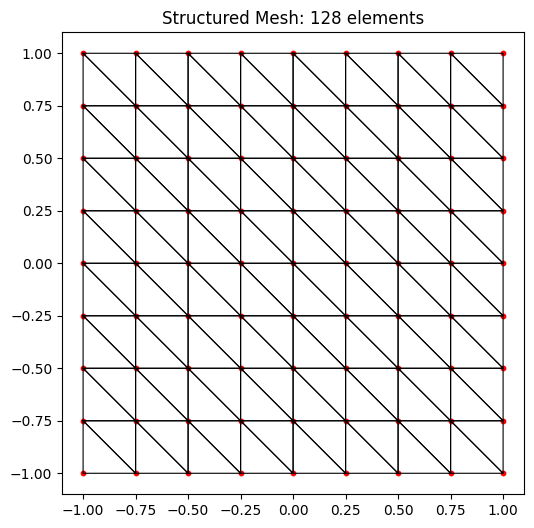

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from localtfem.geometry.structured_mesh import structured_mesh

mesh = structured_mesh(level=2)  # try 1–4
mesh.num_nodes, mesh.num_elements, mesh.num_edges

def plot_mesh(mesh):
    nodes = mesh.nodes
    elems = mesh.elements

    plt.figure(figsize=(6, 6))

    for tri in elems:
        x = nodes[tri, 0]
        y = nodes[tri, 1]

        x = np.append(x, x[0])
        y = np.append(y, y[0])

        plt.plot(x, y, color="black", linewidth=0.8)

    plt.scatter(nodes[:, 0], nodes[:, 1], s=10, color="red")

    plt.gca().set_aspect("equal")
    plt.title(f"Structured Mesh: {mesh.num_elements} elements")
    plt.show()

plot_mesh(mesh)    